In [47]:
# -------------------- LangGraph --------------------
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt, Command


# -------------------- Python --------------------
import os
import sqlite3
import tempfile
from typing import Annotated, Any, Dict, Optional, TypedDict


# -------------------- Environment --------------------
from dotenv import load_dotenv


# -------------------- LangChain Core --------------------
from langchain_core.messages import BaseMessage, SystemMessage,HumanMessage, AIMessage
from langchain_core.tools import tool


# -------------------- LangChain --------------------
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.vectorstores import FAISS
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

# -------------------- LLM + Embeddings --------------------
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings


# -------------------- Other --------------------
import requests

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import interrupt, Command

In [48]:
load_dotenv()

subgraph_llm = ChatGroq(model='llama-3.3-70b-versatile')
parent_llm = ChatGroq(model='llama-3.3-70b-versatile')
llm = ChatGroq(model='llama-3.3-70b-versatile')


In [49]:
# Load PDF
loader = PyPDFLoader('Assignment-1.pdf')
docs = loader.load()
# Split PDF
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)
# Embeddings of PDF
embeddings = HuggingFaceEmbeddings(model="BAAI/bge-large-en-v1.5")
vector_store = FAISS.from_documents(chunks, embeddings)
# Retriever
retriever = vector_store.as_retriever(search_type='similarity',search_kwargs={'k':4})

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2151.62it/s]


In [50]:
# Tools
search = DuckDuckGoSearchRun(region='us-en')

@tool
def rag_tool(query):
    '''
    Retrieve relevent information from pdf
    '''
    result = retriever.invoke(query)
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return {
        'result': result,
        'context': context,
        'metadata': metadata
    }
    
tools = [search,rag_tool]
llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [51]:
# Define States
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# How many Tokens we used after that it will automatically trim the messages
MAX_TOKENS = 200

In [52]:
# Define Node
def chat_node(state: ChatState):
    messages = state['messages']
    # messages = trim_messages(
    #    state['messages'],
    #    strategy='last',
    #    max_tokens= MAX_TOKENS,
    #    token_counter=count_tokens_approximately 
    # )
    response = llm_with_tools.invoke(messages)
    
    return {
        'messages': [response]
    }

In [53]:
# # Human in the Loop
# def human_review(state: ChatState):

#     decision = interrupt(
#         "LLM wants to use a tool. Allow? yes/no"
#     )

#     if decision == "yes":
#         return state

#     return {
#         "messages": [
#             AIMessage(
#                 content="Tool rejected by user"
#             )
#         ]
#     }
    

In [61]:
graph = StateGraph(ChatState)

# Nodes
graph.add_node('chat',chat_node)
# graph.add_node('human',human_review)
graph.add_node('tools',tool_node)


# Edges
graph.add_edge(START, 'chat')
# graph.add_conditional_edges('chat', tools_condition,{
#         "tools": "human",
#         "__end__": END
#     })
# graph.add_edge('human', 'tools')

graph.add_conditional_edges(
    "chat",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)


# After tool → back to chat
graph.add_edge(
    "tools",
    "chat"
)

In [59]:
# Checkpointer
conn = sqlite3.connect('database1.db', check_same_thread=False )
checkpointer = SqliteSaver(conn=conn)

In [62]:
chatbot = graph.compile(checkpointer=checkpointer)

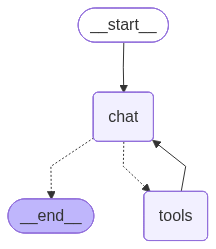

In [63]:
chatbot

In [64]:
# Add threads
config = {'configurable':{'thread_id':'thread-1'}}

In [65]:
# chatbot.invoke(
#     Command(resume="yes"),
#     config=config
# )

In [68]:
result = chatbot.invoke({'messages': [HumanMessage(content='Search for latest news about ai?')]},config=config)
print(result['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


KeyboardInterrupt: 